In [48]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

if torch.cuda.is_available():
    GPU = torch.cuda.get_device_name()
    device = torch.device('cuda')
    if device.type == 'cuda':
        print(GPU)

NVIDIA GeForce RTX 5060 Ti


In [49]:
torch.manual_seed(234)

class AmericanOptionLSM:
    def __init__(self, S0, K, r, sigma, T, M, I):
        self.S0 = S0
        self.K = K
        self.r = r
        self.sigma = sigma
        self.T = T
        self.M = M
        self.I = I
        self.dt = T / M
        self.df = torch.exp(torch.tensor(-r * self.dt, device=device)) # discount factor

    def generate_paths(self):
        '''Paths with Weiner Process'''
        S = torch.zeros((self.M + 1, self.I), device=device)
        S[0] = self.S0
        
        # R.V. from Standard Normal
        rn = torch.randn((self.M + 1, self.I), device=device)
        
        drift = (self.r - 0.5 * self.sigma ** 2) * self.dt
        diffusion = self.sigma * torch.sqrt(torch.tensor(self.dt, device=device))
        
        log_returns = drift + diffusion * rn[1:]
        S[1:] = self.S0 * torch.exp(torch.cumsum(log_returns, dim=0))
        return S

    def run_lsm(self, basis_degree=2):
        S = self.generate_paths()
        h = torch.maximum(self.K - S, torch.tensor(0.0, device=device))
        V = h[-1].clone() 

        # Condtion Number
        cond_nums = []
        # Backward Induction
        for t in range(self.M - 1, 0, -1):
            itm_mask = h[t] > 0
            itm_indices = torch.nonzero(itm_mask).flatten()
            
            # for non itm paths
            if itm_indices.numel() == 0:
                V *= self.df
                continue

            # for itm paths
            X = S[t, itm_indices]
            Y = V[itm_indices] * self.df
            
            # LINEAR ALGEBRA IS HERE!!!
            A = torch.vander(X, N=basis_degree + 1)
            A = torch.flip(A, dims=[1])
            
            if self.I <= 100000: 
                cond_nums.append(torch.linalg.cond(A).item())
            
            # Least Squares Method for Coefficients
            lstsq_result = torch.linalg.lstsq(A, Y, rcond=None)
            beta = lstsq_result.solution
            
            # Projection
            continuation_value = A @ beta
            
            exercise_value = h[t, itm_indices]
            do_exercise = exercise_value > continuation_value
            
            V *= self.df
            exercise_indices = itm_indices[do_exercise]
            V[exercise_indices] = exercise_value[do_exercise]
        
        price = torch.mean(V * self.df)
        avg_cond = torch.tensor(cond_nums).mean().item() if cond_nums else 0.0
        return price.item(), avg_cond


In [50]:
def the_8_paths():
    '''Replicate Numerical Example in paper'''
    
    # Data given in the paper
    S_data = [
        [1.00, 1.09, 1.08, 1.34],
        [1.00, 1.16, 1.26, 1.54],
        [1.00, 1.22, 1.07, 1.03],
        [1.00, 0.93, 0.97, 0.92],
        [1.00, 1.11, 1.56, 1.52],
        [1.00, 0.76, 0.77, 0.90],
        [1.00, 0.92, 0.84, 1.01],
        [1.00, 0.88, 1.22, 1.34]]
    S = torch.tensor(S_data, device=device)
    K = 1.10
    r = 0.06
    dt = 1.0
    df = torch.exp(torch.tensor(-r * dt, device=device))
    
    # take t=2
    t = 2
    print(f'--- Time Step t={t} ---')
    
    # Payoff in t=3
    CF_t3 = torch.maximum(K - S[:, 3], torch.tensor(0.0, device=device))
    
    # ITM paths for t=2
    itm_mask = S[:, t] < K
    itm_indices = torch.nonzero(itm_mask).flatten()
    print(f'ITM Paths Indices (0-based): {itm_indices.cpu().numpy()}')
    
    X = S[itm_indices, t]
    Y = CF_t3[itm_indices] * df
    
    # Matrix: [1, X, X^2]
    A = torch.vander(X, N=3)
    A = torch.flip(A, dims=[1]) # [Fix] 使用 flip
    
    # L-S
    result = torch.linalg.lstsq(A, Y, rcond=None)
    beta = result.solution
    
    continuation_value = A @ beta
    exercise_value = K - X
    do_exercise = exercise_value > continuation_value
    
    print('\n[Matrices Visualization]')
    print(f'Matrix A (Basis: 1, X, X^2):\n{A.cpu().numpy()}')
    print(f'Target Vector Y (Discounted Cashflow):\n{Y.cpu().numpy()}')
    print(f'Coefficients:\n{beta.cpu().numpy()}')
    print('-' * 30)
    print(f'Estimated Continuation Value:\n{continuation_value.cpu().numpy()}')
    print(f'Immediate Exercise Value:\n{exercise_value.cpu().numpy()}')
    print(f'Decision (True = Exercise):\n{do_exercise.cpu().numpy()}')
    

--- Time Step t=2 ---
ITM Paths Indices (0-based): [0 2 3 5 6]

[Matrices Visualization]
Matrix A (Basis: 1, X, X^2):
[[1.         1.08       1.1664001 ]
 [1.         1.07       1.1449001 ]
 [1.         0.97       0.9409    ]
 [1.         0.77       0.5929    ]
 [1.         0.84       0.70559996]]
Target Vector Y (Discounted Cashflow):
[0.         0.06592357 0.16951764 0.18835296 0.08475885]
Coefficients:
[-1.0699897  2.983416  -1.8135796]
------------------------------
Estimated Continuation Value:
[0.03674054 0.0458982  0.11752701 0.15196943 0.15641809]
Immediate Exercise Value:
[0.01999998 0.02999997 0.13       0.33000004 0.26000005]
Decision (True = Exercise):
[False False  True  True  True]

Simulating 50000 paths with 50 time steps
Degree 1: Price = 4.4240, Avg Cond Num = 421.43
Degree 2: Price = 4.4659, Avg Cond Num = 165123.62
Degree 3: Price = 4.4875, Avg Cond Num = 66665984.00
Degree 4: Price = 4.4707, Avg Cond Num = 10886560768.00
Degree 5: Price = 4.4714, Avg Cond Num = 102

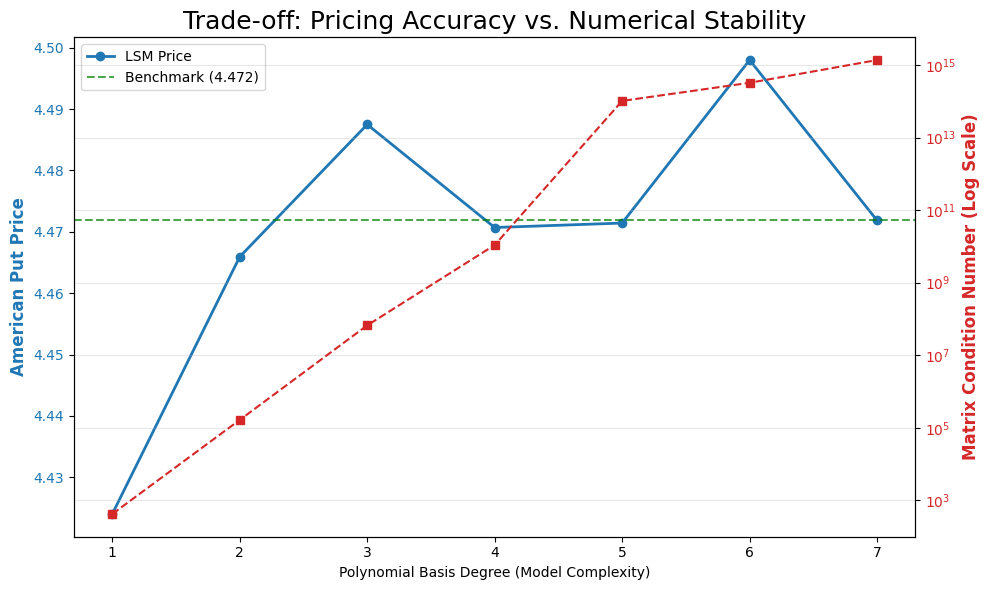

In [51]:
if __name__ == "__main__":
    the_8_paths()
    print('\n' + '='*50)
    
    # Parameters
    S0 = 36.0
    K = 40.0
    r = 0.06
    sigma = 0.2
    T = 1.0
    M = 50
    I = 50000
    
    print(f'Simulating {I} paths with {M} time steps')
    model = AmericanOptionLSM(S0, K, r, sigma, T, M, I)
    
    results = []
    degrees = [1, 2, 3, 4, 5, 6, 7]
    
    for deg in degrees:
        price, avg_cond = model.run_lsm(basis_degree=deg)
        results.append({'Degree': deg, 'Price': price, 'Avg_Condition_Num': avg_cond})
        print(f'Degree {deg}: Price = {price:.4f}, Avg Cond Num = {avg_cond:.2f}')
    
    # Plotting
    df_res = pd.DataFrame(results)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Left Side Axis: American Option Price
    color = 'tab:blue'
    ax1.set_xlabel('Polynomial Basis Degree (Model Complexity)')
    ax1.set_ylabel('American Put Price', color=color, fontsize=12, fontweight='bold')
    ax1.plot(df_res['Degree'], df_res['Price'], color=color, marker='o', linewidth=2, label='LSM Price')
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Benchmark in the paper: 4.472
    ax1.axhline(y=4.472, color='green', linestyle='--', alpha=0.7, label='Benchmark (4.472)')
    ax1.legend(loc='upper left')

    # Right Side Axis: Condition Number
    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Matrix Condition Number (Log Scale)', color=color, fontsize=12, fontweight='bold')
    ax2.plot(df_res['Degree'], df_res['Avg_Condition_Num'], color=color, marker='s', linestyle='--', label='Avg Condition Num')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_yscale('log')
    
    plt.title('Trade-off: Pricing Accuracy vs. Numerical Stability', fontsize=18)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    